<a href="https://colab.research.google.com/github/MBKNgcobo/GF.github.io/blob/main/Copy_of_Catfish_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

In [ ]:
!pip install numpy

In [ ]:
!pip install seaborn

In [ ]:
!pip install matplotlib

In [ ]:
uploaded = files.upload()

Saving catfish.csv to catfish.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose


In [ ]:
df = pd.read_csv("/content/sample_data/catfish.csv")

In [ ]:
df.head()

,Date,Total
0,1986-1-01,9034
1,1986-2-01,9596
2,1986-3-01,10558
3,1986-4-01,9002
4,1986-5-01,9239


In [ ]:
df.dtypes

,0
Date,object
Total,int64


In [ ]:
print(df.shape)


(324, 2)


In [ ]:
print(df.shape)

print("Data Types", df.dtypes)
print("Descriptive stats:", df['Total'].describe())

missing_vals = df['Total'].isna().sum()
print(f"\nMissing Total values: {missing_vals}")

(324, 2)
Data Types Date     object
Total     int64
dtype: object
Descriptive stats: count      324.000000
mean     19626.058642
std       5747.685442
min      -7619.000000
25%      15675.250000
50%      19660.500000
75%      23722.250000
max      46382.000000
Name: Total, dtype: float64

Missing Total values: 0


In [ ]:
df.head()

,Date,Total
0,1986-1-01,9034
1,1986-2-01,9596
2,1986-3-01,10558
3,1986-4-01,9002
4,1986-5-01,9239


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors="coerce")
df.dtypes

,0
Date,datetime64[ns]
Total,int64


In [ ]:
df = df.dropna(subset=['Date']).sort_values('Date')

In [ ]:
# Keep Date both as index and column
df = df.set_index('Date', drop=False)

In [ ]:
#infer the frequency of the data
df = df.asfreq(pd.infer_freq(df.index))

In [ ]:
print(pd.infer_freq(df.index))

MS


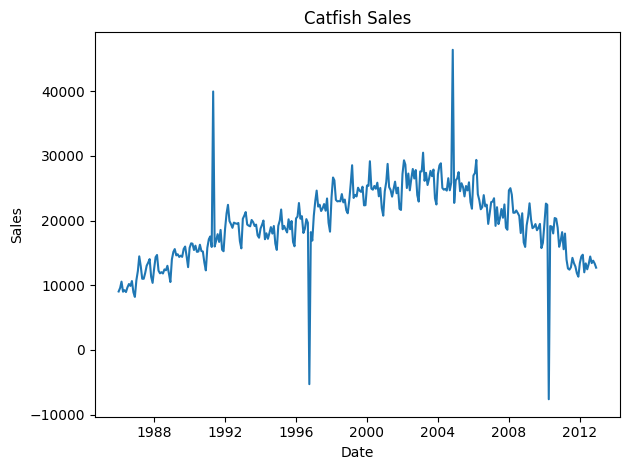

In [ ]:
# Visualizing
ax = sns.lineplot(data=df, x="Date", y="Total")
ax.set(title="Catfish Sales", xlabel="Date", ylabel="Sales")
plt.tight_layout();
plt.show()


In [ ]:
# STL (Loess),  Pearson correlation, Cross correlation, Granger casaulty

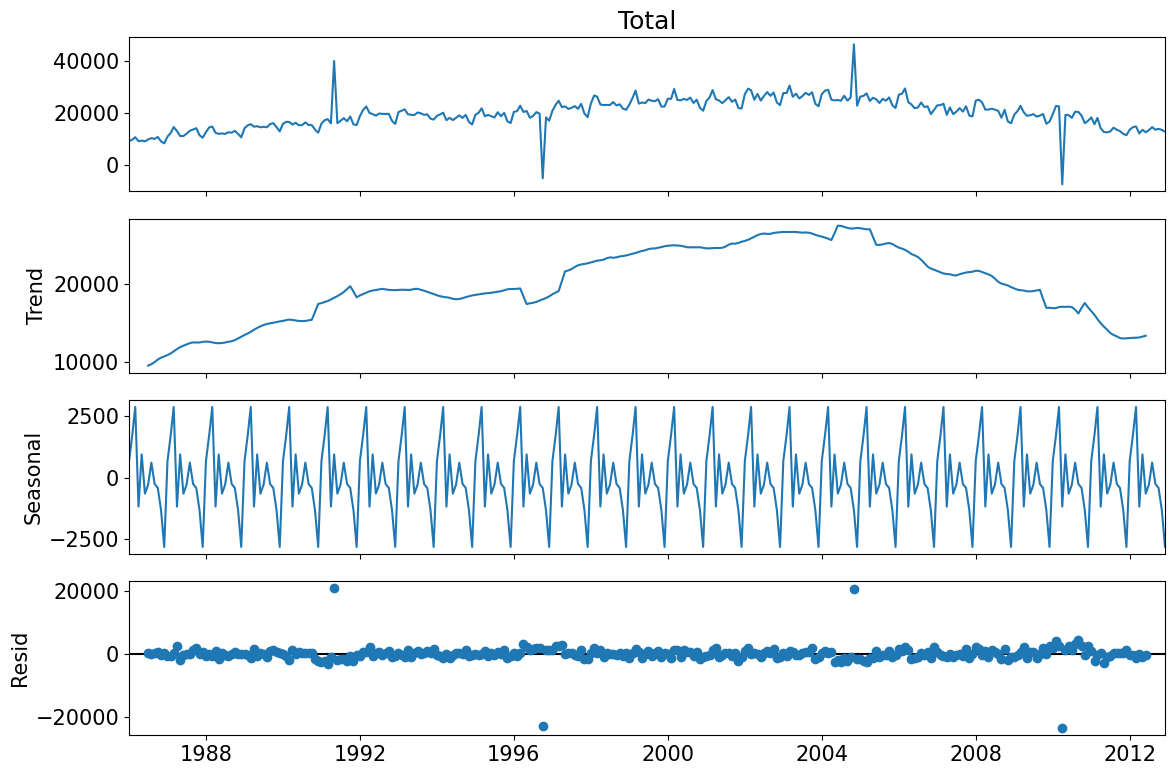

In [ ]:
# Seasonal Decomposition
s = df['Total'].astype('float')
s = s.asfreq(df.index.freq)                       # keep the regular grid
s = s.interpolate('time').ffill().bfill()

plt.rc('figure',figsize=(12,8))
plt.rc('font',size=15)

result = seasonal_decompose(s,model='additive')
fig = result.plot()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.covariance import EllipticEnvelope



In [ ]:
# Normalization

scaler = StandardScaler()






In [ ]:
# Normalization

#Reshape
rx = df['Total'].values.reshape(-1, 1)

np_scaled = scaler.fit_transform(rx)
catfish_data = pd.DataFrame(np_scaled)

In [ ]:
# Training the Isolation Forest
# Hyperparameter tuning.....
istr = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
pred = istr.fit_predict(catfish_data)




In [ ]:
df['anomaly'] = istr.fit_predict(catfish_data)

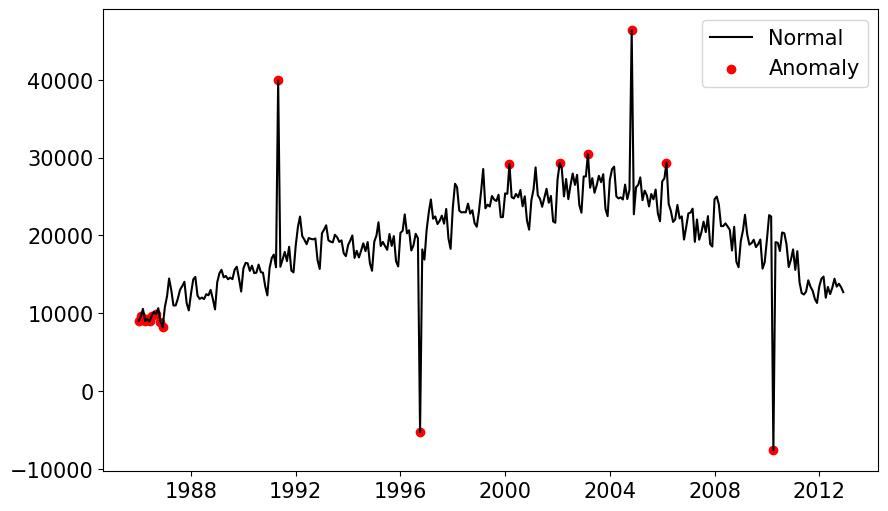

In [ ]:
# visualization
fig, ax = plt.subplots(figsize=(10,6))

a = df.loc[df['anomaly'] == -1, ['Total']] #anomaly

ax.plot(df.index, df['Total'], color='black', label = 'Normal')
ax.scatter(a.index,a['Total'], color='red', label = 'Anomaly')
plt.legend()
plt.show();

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score

In [ ]:
#Anomaly column
df['Anomaly'] = (df['anomaly'] == -1)

# Exporting data with anomalies
df.to_csv('catfish_with_anomaly.csv', index=False, encoding='utf-8')
df.to_excel('catfish_with_anomaly.xlsx', index=False)

In [ ]:
import numpy as np


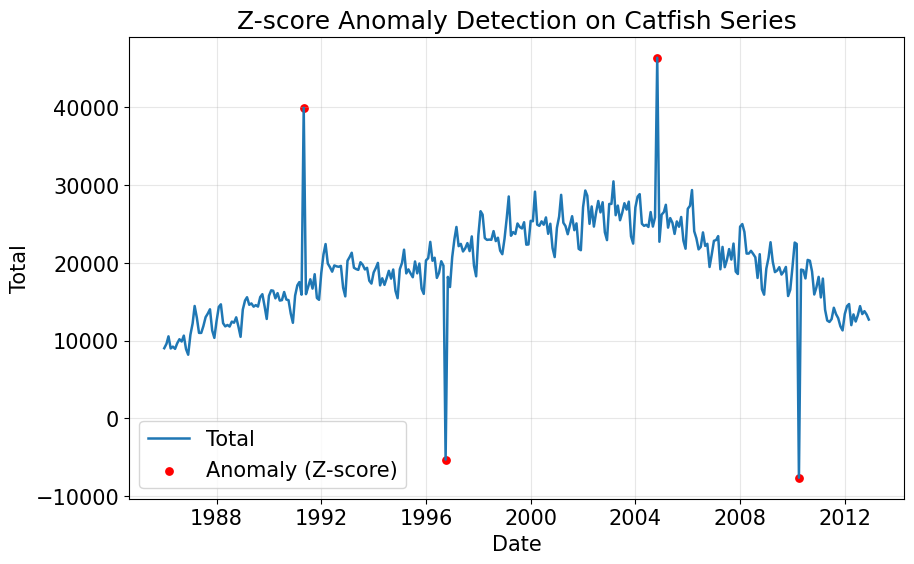

In [ ]:
# Z score


# Z-score = (value - mean) / standard deviation
mean_val = df['Total'].mean()
std_val = df['Total'].std()
df['z_score'] = (df['Total'] - mean_val) / std_val

# Step 3: Define anomalies  |z| > 3

df['Anomaly'] = np.where(np.abs(df['z_score']) > 3, 1, 0)

# Save to Excel
df.to_excel("catfish_with_zscore_anomaly.xlsx", index=True)

# Visualize
fig, ax = plt.subplots(figsize=(10,6))

# Plot the entire series
ax.plot(df.index, df['Total'], label='Total', linewidth=1.8)

# Highlight anomalies
anoms = df[df['Anomaly'] == 1]
ax.scatter(anoms.index, anoms['Total'], color='red', label='Anomaly (Z-score)', s=28)

# Add labels and legend
ax.set_title('Z-score Anomaly Detection on Catfish Series')
ax.set_xlabel('Date')
ax.set_ylabel('Total')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


Silhouette Score: 0.5715405903869006


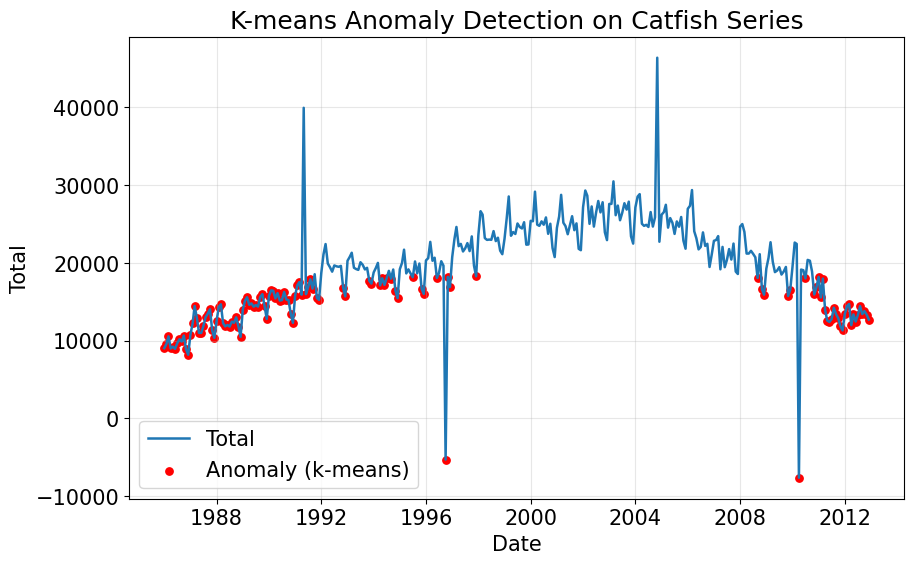

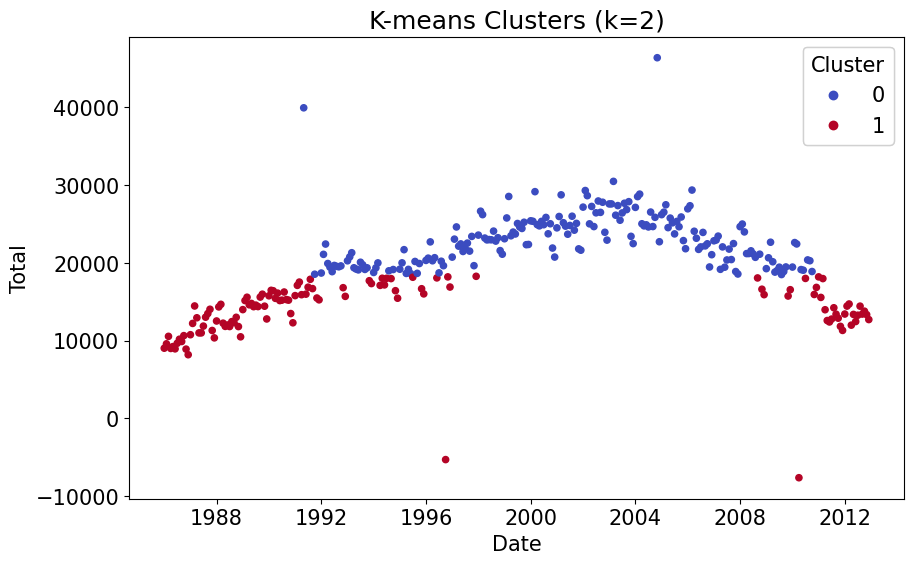

In [ ]:
# Clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Elbow method

s = df[['Total']].astype(float).dropna()
scaler = StandardScaler()
X = scaler.fit_transform(s)

# Run K-means clustering with 2 groups
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
labels = kmeans.fit_predict(X)

# Add cluster labels and mark anomalies (1 = anomaly, 0 = normal)
df['cluster'] = labels


# Check how "good" the clustering is
sil_score = silhouette_score(X, labels)
print("Silhouette Score:", sil_score)

# Visualizing graph
fig, ax = plt.subplots(figsize=(10,6))

# Plot the whole series
ax.plot(df.index, df['Total'], label='Total', linewidth=1.8)

# Plot anomalies as red dots
anoms = df[df['cluster'] == 1]
ax.scatter(anoms.index, anoms['Total'], color='red', label='Anomaly (k-means)', s=28)

# Add labels and legend
ax.set_title('K-means Anomaly Detection on Catfish Series')
ax.set_xlabel('Date')
ax.set_ylabel('Total')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Visualize clusters
fig, ax = plt.subplots(figsize=(10,6))
scatter = ax.scatter(df.index, df['Total'], c=df['cluster'], cmap='coolwarm', s=20)

ax.set_title('K-means Clusters (k=2)')
ax.set_xlabel('Date')
ax.set_ylabel('Total')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.show()

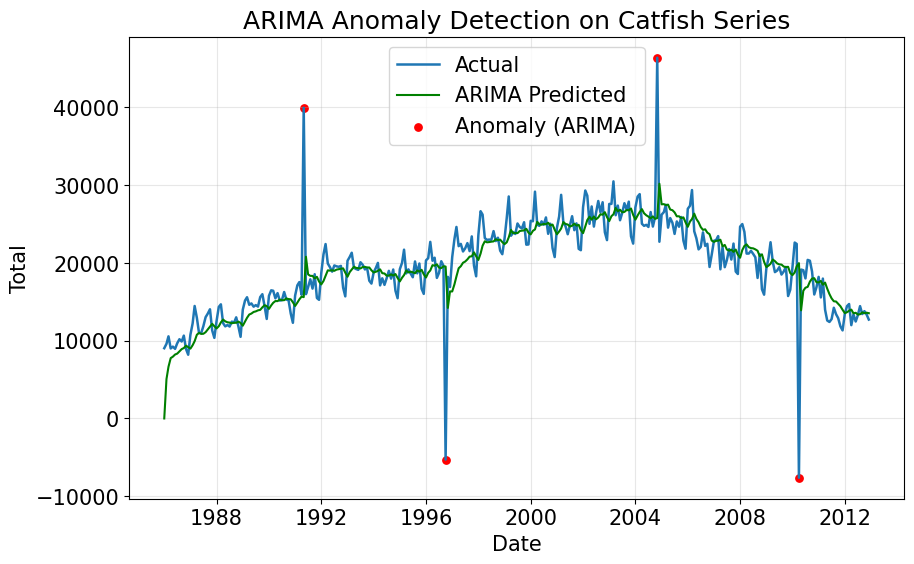

In [ ]:
# ARIMA Autoregressive Integrated Moving Average  forecasting/ anomaly detection
from statsmodels.tsa.arima.model import ARIMA


# Fit a simple ARIMA model
# (p,d,q) = (1,1,1)
model = ARIMA(df['Total'], order=(1,1,1))
model_fit = model.fit()

# Get fitted (predicted) values from the model
df['predicted'] = model_fit.fittedvalues

# Calculate residuals (difference between actual and predicted)
df['residual'] = df['Total'] - df['predicted']

# Define anomalies
# Residual is more than 3 standard deviations away is anomaly
threshold = 3 * df['residual'].std()
df['Anomaly'] = np.where(np.abs(df['residual']) > threshold, 1, 0)

# Save results to Excel
df.to_excel("catfish_with_arima_anomaly.xlsx", index=True)

# Visualize
fig, ax = plt.subplots(figsize=(10,6))

# Plot actual series
ax.plot(df.index, df['Total'], label='Actual', linewidth=1.8)

# Plot ARIMA fitted line
ax.plot(df.index, df['predicted'], color='green', label='ARIMA Predicted', linewidth=1.5)

# Highlight anomalies
anoms = df[df['Anomaly'] == 1]
ax.scatter(anoms.index, anoms['Total'], color='red', label='Anomaly (ARIMA)', s=28)

# Labels and legend
ax.set_title('ARIMA Anomaly Detection on Catfish Series')
ax.set_xlabel('Date')
ax.set_ylabel('Total')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


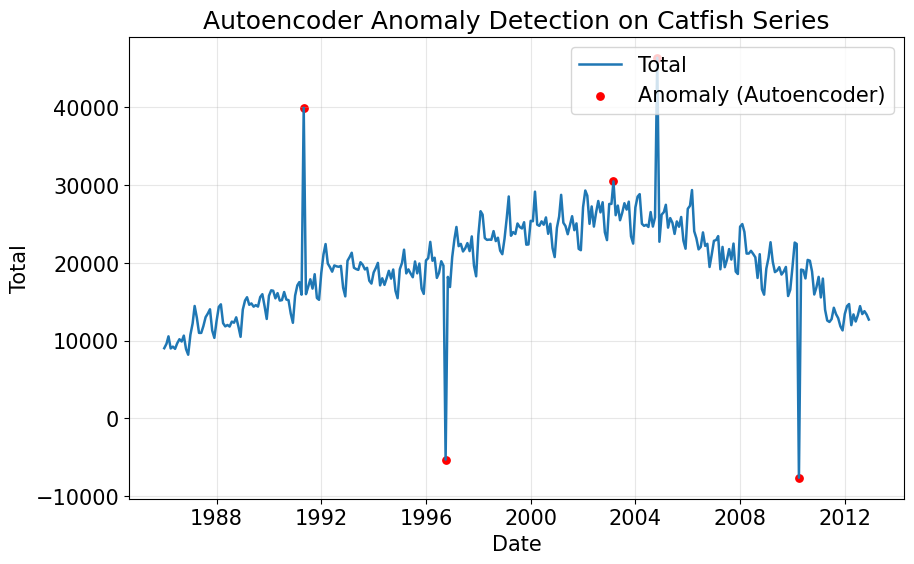

In [ ]:
# Auto encoder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


scaler = MinMaxScaler()
X = scaler.fit_transform(df[['Total']].astype(float))


# Input → compress → reconstruct output
autoencoder = Sequential([
    Dense(8, activation='relu', input_shape=(1,)),  # small hidden layer
    Dense(1, activation='linear')                   # output = reconstruct input
])

autoencoder.compile(optimizer='adam', loss='mse')

#  Train the autoencoder

autoencoder.fit(X, X, epochs=50, batch_size=16, shuffle=True, verbose=0)

# Reconstruction errors
X_pred = autoencoder.predict(X)
recon_error = np.abs(X.flatten() - X_pred.flatten())

# Define anomalies
# Error greater than 3× the standard deviation is anomaly
threshold = 3 * np.std(recon_error)
df['Anomaly'] = np.where(recon_error > threshold, 1, 0)

# Save results to Excel
df.to_excel("catfish_with_autoencoder_anomaly.xlsx", index=True)

# Visualize
fig, ax = plt.subplots(figsize=(10,6))

# Plot series
ax.plot(df.index, df['Total'], label='Total', linewidth=1.8)

# Highlight anomalies
anoms = df[df['Anomaly'] == 1]
ax.scatter(anoms.index, anoms['Total'], color='red', label='Anomaly (Autoencoder)', s=28)

ax.set_title('Autoencoder Anomaly Detection on Catfish Series')
ax.set_xlabel('Date')
ax.set_ylabel('Total')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [ ]:
from sklearn.linear_model import Lasso, Ridge, LogisticRegression

# Regression
lasso = Lasso(alpha=0.1)  # L1, larger alpha = more sparsity
ridge = Ridge(alpha=1.0)  # L2, larger alpha = more shrinkage

# Classification
logreg_l1 = LogisticRegression(penalty='l1', solver='saga', C=1.0)   # C is 1/λ
logreg_l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0)
